# Dialogue evaluation

In [1]:
from cltl.dialogue_evaluation.statistical_evaluation import StatisticalEvaluator
from cltl.dialogue_evaluation.likelihood_evaluation import LikelihoodEvaluator
from cltl.dialogue_evaluation.graph_evaluation import GraphEvaluator
from cltl.dialogue_evaluation.manual_evaluation import ManualEvaluator
import cltl.dialogue_evaluation.plot_interaction as plot

from emissor.persistence import ScenarioStorage
from emissor.persistence.persistence import ScenarioController
from emissor.processing.api import SignalProcessor
from emissor.representation.scenario import Modality, Signal

In [2]:
EMISSOR="./emissor"
#### The next scenario is created by interacting with the Ai2Thor platform.
SCENARIO="7a201bea-3e2f-4dc2-ac36-a628ea4775cd"

## Statistical analysis of the interaction

The statistical analysis of the interaction will count the structural properties. These properties cover:

1. Properties of the scenario:
* the interlocutor names
* the location of the interaction
* any objects and people present
* the duration
2. The text signals exchanged during the interaction
* the number of text signals (utterances from the interlocutors)
* the average utterance length, average number of tokens per uterance and the average token length
* the annotations of the signals
3. The image signals exchanged during the interaction
* the number of image signals
* the annotations of the signals

All signals should at least have an annotation for the source of the signal. In the case of text signals this is the speaker. 
In the case of an image signal this is usually the agent.

Any other interpretations of the signals should be added by annotation software. 
In the notebook ```emissor_scenario_annotation.ipynb```, we showed a number of annotators for text signals.
In the Leolani platform, there are also other annotators for image signals and for extracting triples from text signals.

The statistical analysis provides the counts for the any annotation that is represented in EMISSOR.

Note that EMISSOR is an open framework that can be used to add any type of analysis as an anotator and even add other types of signals.
The complete Leolani application that uses a robot as a backend annotates multimodal signals.

To generate a statistical analysis, you need to create an instance of the ```StatisticalEvaluator``` and call the ```evaluate_conversation``` function with the path to the EMISSOR folder and the name of the scenario, which is a subdirectory in the emissor folder:

In [9]:
## Statistical analysis
statistical_evaluator = StatisticalEvaluator()
statistical_evaluator.analyse_interaction_json(EMISSOR, SCENARIO)

2024-11-21 16:07:52 -     INFO -                cltl.dialogue_evaluation.StatisticalEvaluator - Booted


No location id in context
No location id in context
No location id in context
Saving the meta data in ./emissor/d5a6bc60-c19b-4c08-aee5-b4dd1c65c64d/evaluation/d5a6bc60-c19b-4c08-aee5-b4dd1c65c64d_meta_data.json


The evaluator creates a subfolder ```evaluation``` inside the scenario with a JSON file that contains an overview of the properties and the statistics. In the above scenario these can be found in ```7a201bea-3e2f-4dc2-ac36-a628ea4775cd_meta_data.json```.

## Likelihood analysis

In the annotation notebook, we have seen that we can add the likelihood as an annotation to each text signal. We can call the same function also to create a likelihood evaluation for each utterance in a sequence and the interations overall. This approach was proposed by:

```Mehri, S., & Eskenazi, M. (2020). USR: An unsupervised and reference free evaluation metric for dialog generation. arXiv preprint arXiv:2005.00456.```

They finetuned a RoBERTa model (USR) specifically to mimic human evaluation, as a reference-free approach. Reference-free means that is does not need a human-created response to compare the system response. Instead it determines the likelihood of the system response given the preceding conversation. The likelihood is calculated by taking the average likelihood of all tokens of the system response according to the model. The USR model was finetuned with conversations from TopicalChat and PersonaChat:

```Karthik Gopalakrishnan, Behnam Hedayatnia, Qinlang Chen, Anna Gottardi, Sanjeev Kwatra, Anu Venkatesh, Raefer Gabriel, Dilek Hakkani-Tur, and Amazon Alexa AI. 2019. Topical-chat: Towards knowledge-grounded open-domain conversations. Proc. Interspeech 2019, pages 1891–1895.```
```Saizheng Zhang, Emily Dinan, Jack Urbanek, Arthur Szlam, Douwe Kiela, and Jason Weston. 2018. Personalizing dialogue agents: I have a dog, do you have pets too? arXiv preprint arXiv:1801.07243.```

Their approach has modertae correlation with human judgments: .42 (TopicalChat) and .48 (PersonaChat). The USR model can be downloaded from the course drive. You can place it anywhere on your local machine and load it in the next likelihood evaluator to score the ineraction. Adapt the path below to your local copy of the model.

Note that you can also use any other BERT or RoBERTa model from [hugggingface.co](https://huggingface.co) to score the likelihood.
In the cell below, we show the path to a local version of USR and some other models on huggingface that can be used. It is also possible to finetune any model with you own data to obtain a likelihood score.

In addition to the path to model or the URI on huugingface, you also need to specify the length of the context (string length) to be considered and the number of predicted tokens to compare the system token with. The context is extended with the previous turns upto the maximum length. The likelihood is the current turn is calculated given the preceding tokens including the context.

Each system token of the uterance under consideration is turned into a masked token to predict the most probable tokens according to the model (cut-off by ```len_top_tokens```). If the system token is in the list, it will receive the score from the model. If it is not in the list, the token scores ```0```.

In [10]:
## Likelihood analysis
model= "../leolani_text_to_ekg/resources/usr-topicalchat-roberta_ft"
### Alternative models on huggingface
#model = "google-bert/bert-base-multilingual-case"
#model = "FacebookAI/xlm-roberta-base"
#model = "FacebookAI/roberta-base"

model_name="USR"
#model_name= "BERT"
#model_name= "XMLR"
#model_name= "RoBERTa"

llh_evaluator = LikelihoodEvaluator(model=model, model_name=model_name, max_context=300, len_top_tokens=20)
llh_evaluator.evaluate_conversation(EMISSOR, SCENARIO)

2024-11-21 16:08:07 -     INFO -                 cltl.dialogue_evaluation.LikelihoodEvaluator - Booted


----------SCENARIO:./emissor, EVALUATION:likelihood metrics---------
Nr of turns: 27 Speakers: {'LEOLANI', 'SPEAKER'} Max context: 300
Processing turn 0/26
	Calculating likelihood scores
Processing turn 1/26
	Calculating likelihood scores
Processing turn 2/26
	Calculating likelihood scores
Processing turn 3/26
	Calculating likelihood scores
Processing turn 4/26
	Calculating likelihood scores
Processing turn 5/26
	Calculating likelihood scores
Processing turn 6/26
	Calculating likelihood scores
Processing turn 7/26
	Calculating likelihood scores
Processing turn 8/26
	Calculating likelihood scores
Processing turn 9/26
	Calculating likelihood scores
Processing turn 10/26
	Calculating likelihood scores
Processing turn 11/26
	Calculating likelihood scores
Processing turn 12/26
	Calculating likelihood scores
Processing turn 13/26
	Calculating likelihood scores
Processing turn 14/26
	Calculating likelihood scores
Processing turn 15/26
	Calculating likelihood scores
Processing turn 16/26
	Calc

## Plot analysis of the interaction

Positive and negative scoring of GO emotion labels:

```
negative = ["remorse", "nervousness", "fear", "sadness", "embaressement", "disappointment", "grief", "disgust", "anger", "annoyance", "disapproval", "confusion"]
positive = ["joy", "amusement","excitement", "love", "desire", "optimism", "caring", "pride", "admiration", "gratitude", "belief", "approval", "curiosity"]
```
```
    negative = ["anger", "disgust", "fear", "sadness"]
    positive = ["joy"]
```



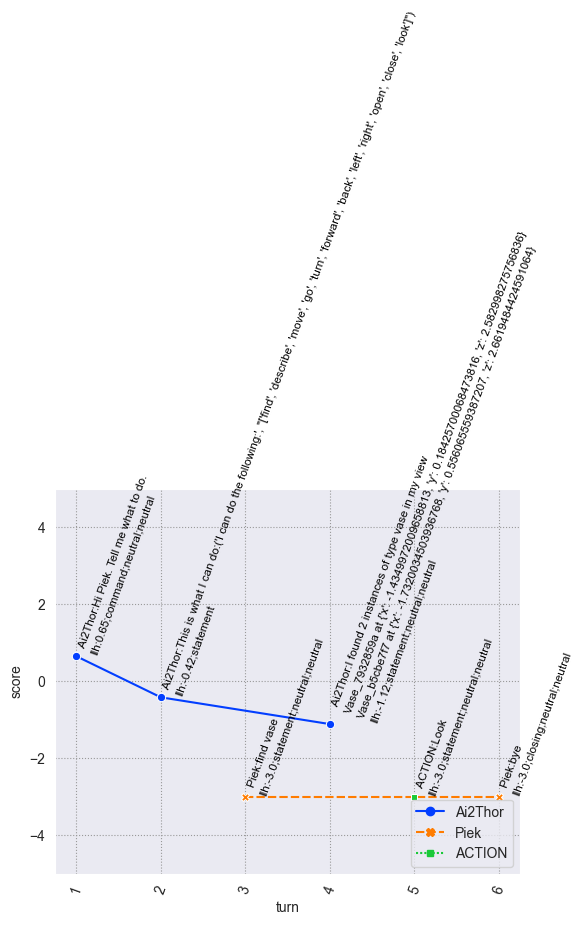

In [5]:
## Plot analysis

settings = plot.PlotSettings()
settings._ANNOTATIONS = 'go,sentiment,llh'
settings._SENTIMENT_THRESHOLD=0.7
settings._LLH_THRESHOLD=0.3

scenario_storage = ScenarioStorage(EMISSOR)
scenario_ctrl = scenario_storage.load_scenario(SCENARIO)
speaker = scenario_ctrl.scenario.context.speaker["name"]
agent = scenario_ctrl.scenario.context.agent["name"]
text_signals = scenario_ctrl.get_signals(Modality.TEXT)

plot.create_timeline_image(scenario_path=EMISSOR, 
                           scenario=SCENARIO,
                           speaker=speaker, 
                           agent=agent,
                           signals=text_signals, 
                           settings=settings)

## Graph analysis

In [6]:
import os

scenario_path = os.path.join(EMISSOR, SCENARIO)
rdf_path = os.path.join(scenario_path, "rdf")
if os.path.exists(rdf_path):
    graph_evaluator = GraphEvaluator()
    graph_evaluator.evaluate_conversation(scenario_path, rdf_folder=rdf_path)
else:
    print("No triples found for", SCENARIO)

No triples found for 7a201bea-3e2f-4dc2-ac36-a628ea4775cd


## Manual evaluation

In [11]:
manual_evaluator = ManualEvaluator()
manual_evaluator.evaluate_conversation(EMISSOR, SCENARIO)

2024-11-21 16:09:10 -     INFO -                     cltl.dialogue_evaluation.ManualEvaluator - Booted


SCENARIO_FOLDER: ./emissor
Nr of turns: 27  extracted from scenario:  d5a6bc60-c19b-4c08-aee5-b4dd1c65c64d
Speakers: {'LEOLANI', 'SPEAKER'}
	Placeholders for manual scores


## Applying the evaluators to another scenario

No location id in context
No location id in context
No location id in context
Saving the meta data in ./emissor/d5a6bc60-c19b-4c08-aee5-b4dd1c65c64d/evaluation/d5a6bc60-c19b-4c08-aee5-b4dd1c65c64d_meta_data.json
----------SCENARIO:./emissor, EVALUATION:likelihood metrics---------
Nr of turns: 27 Speakers: {'LEOLANI', 'SPEAKER'} Max context: 300
Processing turn 0/26
	Calculating likelihood scores
Processing turn 1/26
	Calculating likelihood scores
Processing turn 2/26
	Calculating likelihood scores
Processing turn 3/26
	Calculating likelihood scores
Processing turn 4/26
	Calculating likelihood scores
Processing turn 5/26
	Calculating likelihood scores
Processing turn 6/26
	Calculating likelihood scores
Processing turn 7/26
	Calculating likelihood scores
Processing turn 8/26
	Calculating likelihood scores
Processing turn 9/26
	Calculating likelihood scores
Processing turn 10/26
	Calculating likelihood scores
Processing turn 11/26
	Calculating likelihood scores
Processing turn 12/26
	Calc

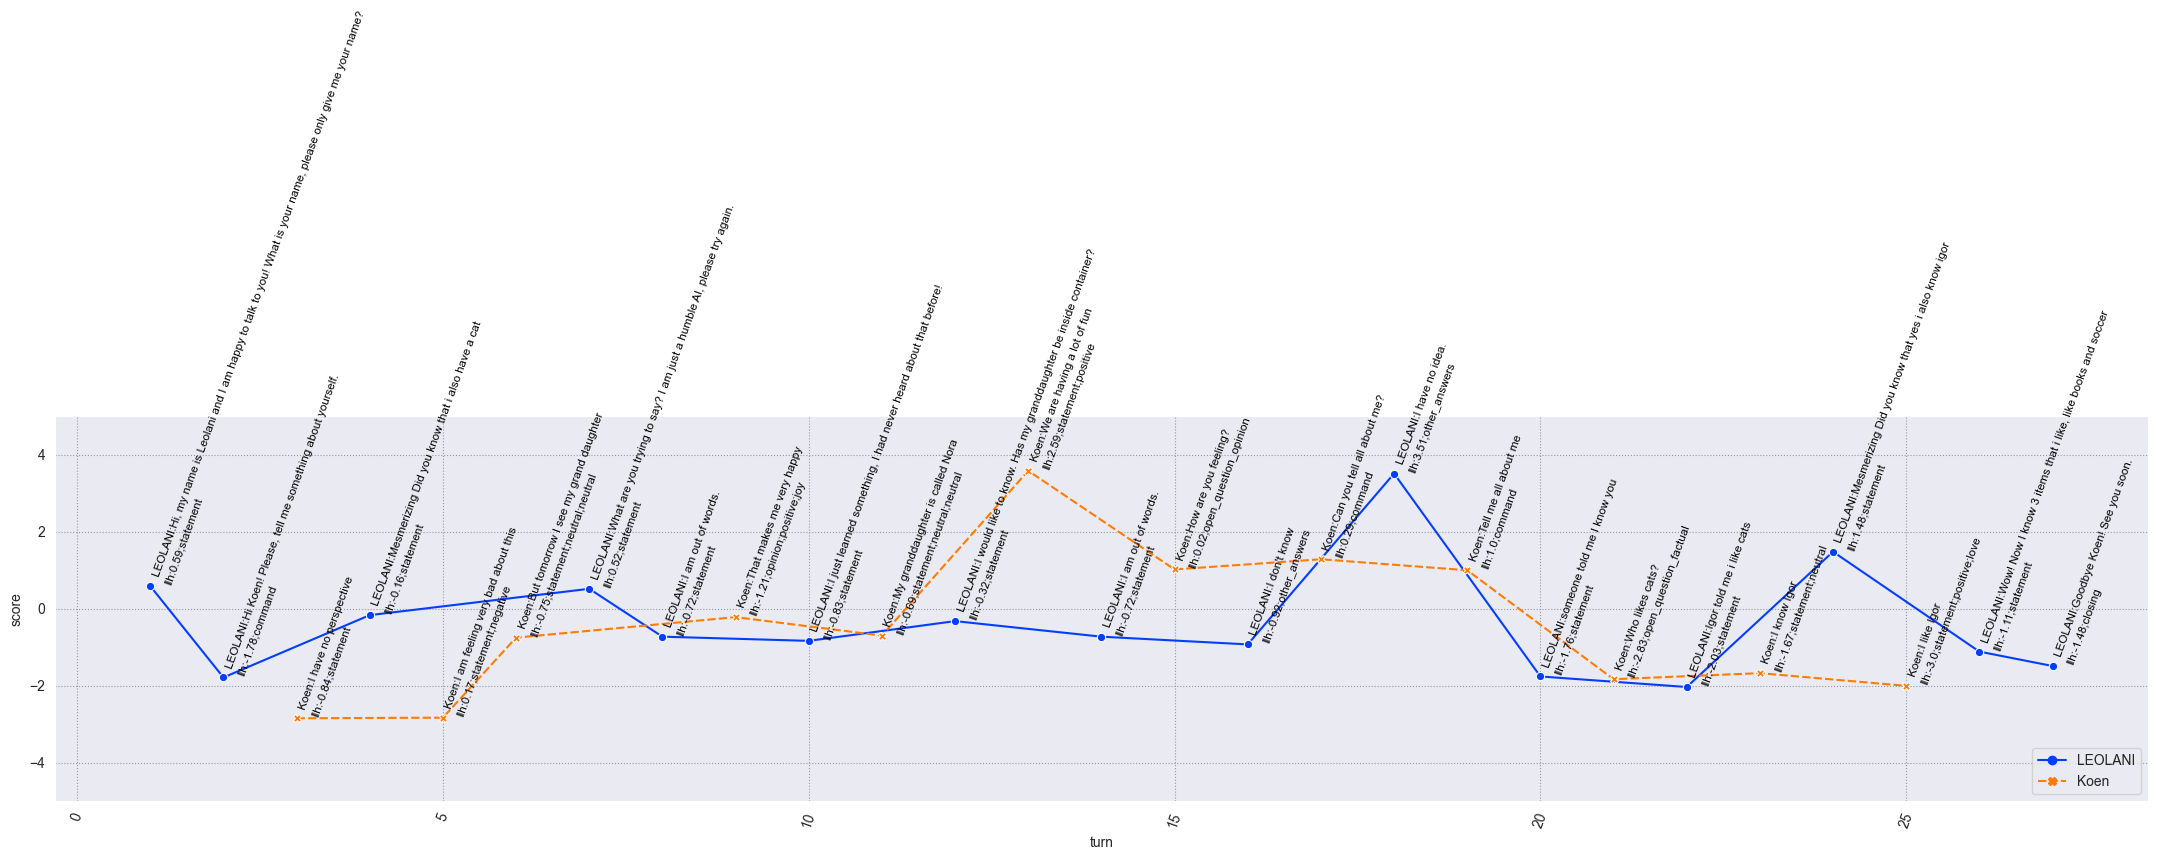

In [12]:
SCENARIO="d5a6bc60-c19b-4c08-aee5-b4dd1c65c64d"

statistical_evaluator.analyse_interaction_json(EMISSOR, SCENARIO)

llh_evaluator.evaluate_conversation(EMISSOR, SCENARIO)

manual_evaluator.evaluate_conversation(EMISSOR, SCENARIO)

scenario_storage = ScenarioStorage(EMISSOR)
scenario_ctrl = scenario_storage.load_scenario(SCENARIO)
speaker = scenario_ctrl.scenario.context.speaker["name"]
agent = scenario_ctrl.scenario.context.agent["name"]
text_signals = scenario_ctrl.get_signals(Modality.TEXT)

plot.create_timeline_image(scenario_path=EMISSOR, 
                           scenario=SCENARIO,
                           speaker=speaker, 
                           agent=agent,
                           signals=text_signals, 
                           settings=settings)

## END